In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [6]:
#TASK1 STARTS

import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
# 11 rows have missing Postal Code but they will not be used in this analysis, so left as is.

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Week'] = df['Order Date'].dt.isocalendar().week
df['Order_DayOfWeek'] = df['Order Date'].dt.day_name()
df['Order_Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Order_Month'].apply(get_season)

df[['Order Date', 'Order_Year', 'Order_Month', 'Order_Week', 'Order_DayOfWeek', 'Order_Quarter', 'Season']].head()

,Order Date,Order_Year,Order_Month,Order_Week,Order_DayOfWeek,Order_Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall


In [18]:
# Monthly totals
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Order Date', 'Total_Sales']

print("Monthly sales shape:", monthly_sales.shape)
monthly_sales.head()

Monthly sales shape: (48, 2)


,Order Date,Total_Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [15]:
# Weekly totals
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_sales.columns = ['Order Date', 'Total_Sales']

print("Weekly sales shape:", weekly_sales.shape)
weekly_sales.head()

Weekly sales shape: (209, 2)


,Order Date,Total_Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [19]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [ ]:
# Which product category generates the highest total revenue?

# Technology generates the highest total revenue at $827,455.87, followed by Furniture ($728,658.58) and Office Supplies ($705,422.33).

In [20]:
# yearly sales per region
region_yearly = df.groupby(['Region', 'Order_Year'])['Sales'].sum().reset_index()

# pivot the table to have years as columns
region_pivot = region_yearly.pivot(index='Region', columns='Order_Year', values='Sales')
print(region_pivot)

# year-over-year growth rate for each region
region_growth = region_pivot.pct_change(axis=1) * 100
print("\nYear-over-year growth (%):")
print(region_growth)

# "Consistent Sales" = low standard deviation of growth rates
consistency = region_growth.std(axis=1)
print("\nStandard deviation of YoY growth (lower = more consistent):")
print(consistency.sort_values())

Order_Year         2015         2016         2017         2018
Region                                                        
Central     102920.5206  102425.1724  145673.8800  141627.3402
East        127652.8190  153225.1830  178511.5380  210129.1860
South       103374.9055   70076.0825   93535.9035  122164.5675
West        145907.9630  133709.5675  182471.2285  248130.9255

Year-over-year growth (%):
Order_Year  2015       2016       2017       2018
Region                                           
Central      NaN  -0.481292  42.224686  -2.777807
East         NaN  20.032745  16.502741  17.711823
South        NaN -32.211708  33.477643  30.607139
West         NaN  -8.360336  36.468341  35.983589

Standard deviation of YoY growth (lower = more consistent):
Region
East        1.793948
Central    25.345279
West       25.743054
South      37.124876
dtype: float64


In [ ]:
# Which region has the most consistent sales growth over 4 years?

# The East region shows the most consistent growth, with a year-over-year growth standard deviation of only 1.79% — far lower than Central (25.3%), West (25.7%), or South (37.1%).
# East grew steadily every single year (+20.0% in 2016, +16.5% in 2017, +17.7% in 2018), with no negative years.

In [21]:
# Calculate shipping duration
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Overall average shipping time:", df['Shipping_Days'].mean().round(2), "days")

# average shipping time by region
shipping_by_region = df.groupby('Region')['Shipping_Days'].mean().sort_values()
print("\nAverage shipping time by region:")
print(shipping_by_region)

Overall average shipping time: 3.96 days

Average shipping time by region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64


In [ ]:
# What is the average time between Order Date and Ship Date — and does it vary by region?

# The overall average shipping time is 3.96 days. Shipping time is fairly consistent across regions, ranging narrowly from 3.91 days (East, fastest) to 4.07 days (Central, slowest) —
# a spread of less than 0.16 days.

In [22]:
month_year_sales = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().reset_index()
month_year_pivot = month_year_sales.pivot(index='Order_Month', columns='Order_Year', values='Sales')
print(month_year_pivot)

Order_Year         2015        2016        2017         2018
Order_Month                                                 
1            14205.7070  18066.9576  18542.4910   43476.4740
2             4519.8920  11951.4110  22978.8150   19920.9974
3            55205.7970  32339.3184  51165.0590   58863.4128
4            27906.8550  34154.4685  38679.7670   35541.9101
5            23644.3030  29959.5305  56656.9080   43825.9822
6            34322.9356  23599.3740  39724.4860   48190.7277
7            33781.5430  28608.2590  38320.7830   44825.1040
8            27117.5365  36818.3422  30542.2003   62837.8480
9            81623.5268  63133.6060  69193.3909   86152.8880
10           31453.3930  31011.7375  59583.0330   77448.1312
11           77907.6607  75249.3995  79066.4958  117938.1550
12           68167.0585  74543.6012  95739.1210   83030.3888


In [ ]:
# Are there months that consistently spike across all years (seasonality)?

# Yes, September and November consistently rank among the highest-revenue months in every single year (2015–2018).

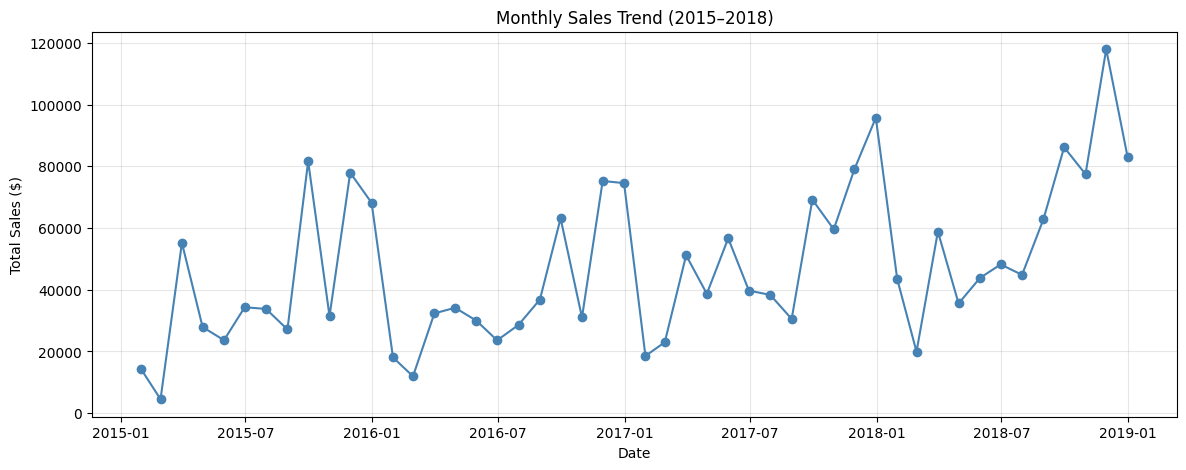

In [24]:
#TASK2 STARTS

# Monthly Sales Trend Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Total_Sales'], marker='o', color='steelblue')
plt.title('Monthly Sales Trend (2015–2018)')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(alpha=0.3)
plt.show()

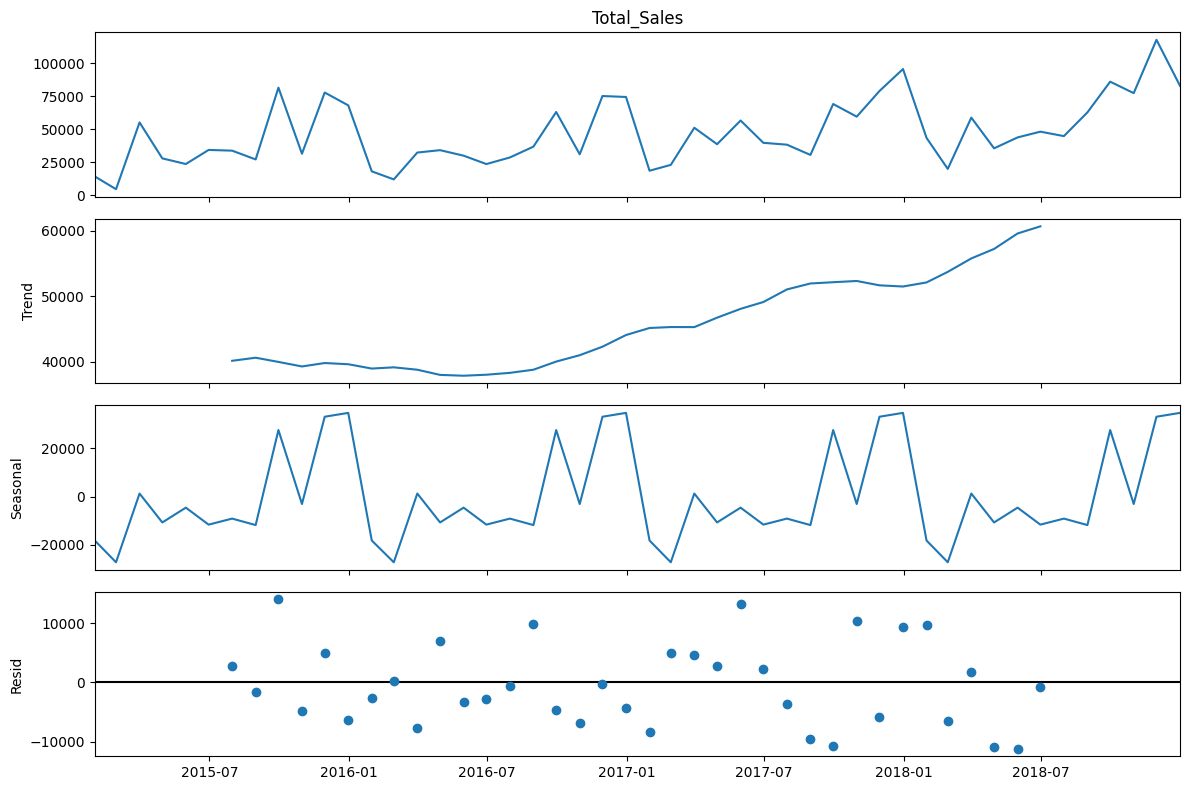

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = monthly_sales.set_index('Order Date')['Total_Sales']

decomposition = seasonal_decompose(ts, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [ ]:
# Decomposition Observations

# Trend: Sales show a clear long-term upward trend, growing from roughly $37,000/month in early 2015 to over $60,000/month by late 2018 — the business is genuinely
#  expanding over the 4-year period, not just fluctuating.

# Seasonality: Seasonality is strong and highly consistent. Every single year shows the same repeating shape: a sharp dip in Jan/Feb (as low as -$25,000 relative to trend), a
#  mid-year rise, and the year's peak in Nov/Dec (+$25,000 to +$27,000). This confirms the seasonality observed in the raw EDA (Q4) is a real, recurring pattern rather than coincidence.

# Residual/Noise: Residuals are scattered between roughly -$11,000 and +$14,000 with no visible pattern, suggesting trend and seasonality explain most of the signal.
#  The largest residual spikes occur around late 2015, mid-2017, and early 2018 — these months saw sales notably different from what trend+seasonality alone would predict.

# Overall: Since seasonal swings stay roughly the same absolute size even as the trend grows, the additive decomposition model was an appropriate choice here
#  (versus multiplicative, which assumes seasonal swings scale up proportionally with the trend).

In [26]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

if result[1] <= 0.05:
    print("\n=> Series is STATIONARY (reject H0)")
else:
    print("\n=> Series is NON-STATIONARY (fail to reject H0)")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values:
   1%: -3.5778480370438146
   5%: -2.925338105429433
   10%: -2.6007735310095064

=> Series is STATIONARY (reject H0)


In [ ]:
# Stationarity Check (ADF Test)

# What is stationarity?
# A time series is stationary if its statistical properties- mean, variance, and autocorrelation- stay roughly constant over time, rather than drifting
# (e.g., a rising trend) or changing shape.

# Since the p-value (0.00028) is well below 0.05, and the ADF statistic is more negative than all critical value thresholds, we reject the null hypothesis-
# the test concludes the series is stationary.

# Note on an apparent contradiction:
# This is somewhat surprising given that the decomposition trend component visibly grows from ~$37K/month in 2015 to ~$60K/month in 2018. Likely explanation:
# the series has very strong, regular seasonal swings (±$25K), which are large relative to the trend's gentler climb- the ADF test appears to weight the series' repeated,
# predictable seasonal reversion more heavily than the underlying gradual trend. With only 48 monthly data points, test power is also limited.

# Decision:
# Since the formal ADF test result is stationary, we do not apply differencing for this series. We proceed with the un-differenced monthly series for SARIMA in Task 3,
# but will let SARIMA's own seasonal "D" and non-seasonal "d" parameters (which handle exactly this kind of trend/seasonality) account for any remaining structure.